This notebook covers making a map with basics of the political and economic map of Reikland. This means sizes of sub-provincial entities, travel distances/times, what gets produced in each administrative district

## Waterways
Here we set up the waterways. The plan is following from the following Gemini prompt that was used to generate the code:

OK, nice. 


Code please. We are using the same gpkg file. The waterway layer is called "reikland_waterways".

Waterway names are in a column "Name". Note that due to cutting segments, we do have repeating names as a feature of the dataset.
Waterway type is stored in a column "Type". To minimize typo risks they are encoded simply as "C" or "R" for canal and river respectively.

Inflow is in a column named "Inflow". We want canals to have sizes typed in by hand by the user - it is not the surrounding river that determines how much effort was spent on making the things. 


In terms of how we want the thing to be set-up:
* We will want four seperate cells
* The first cell loads the data and print the basic stats: number of features (including how many are canal feautres), number of vertices and the number of junctions
* The second cell does data quality control:
    * Checks that there is only one waterway system on the map (i.e. everything is connected)
    * Checks that flow directionalities are all in agreement
    * If anything trips, we need it to return uids of the features to make the QGIS fixing as quick and easy as possible.
* The third cell generates and runs the flow accumulation engine.
* The fourth cell saves the outcomes back into the .gpkg layer as "accumulated_size" column.



In [1]:
import geopandas as gpd
import networkx as nx
import numpy as np

# 1. Load the data
gpkg_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg"
layer_name = "reikland_waterways"

print("Loading waterways...")
# Use a basic SQL query to force GeoPandas to hand over the hidden 'fid' column
waterways = gpd.read_file(gpkg_path, sql=f"SELECT fid, * FROM {layer_name}")

# Set that fid column as the official index for the DataFrame
waterways.set_index('uid', drop=False, inplace=True)

# --- TRACKING DOWN GHOST ROWS ---
initial_count = len(waterways)
ghost_rows = waterways[waterways.geometry.isnull() | waterways.geometry.is_empty]

if not ghost_rows.empty:
    print(f"🧹 FOUND {len(ghost_rows)} 'ghost' rows (features with no geometry).")
    print(f"Ghost row UIDs (check these in QGIS Attribute Table): {ghost_rows['uid'].tolist()}")
    
# Purge the ghosts 
# (Note: we removed the reset_index() line here so our uids stay locked in!)
waterways = waterways[waterways.geometry.notnull() & ~waterways.geometry.is_empty]
# --------------------------------------

# 2. Helper function to extract cleanly rounded start/end nodes
def get_endpoints(geom):
    if geom is None or geom.geom_type != 'LineString':
        return None, None
    coords = list(geom.coords)
    return (round(coords[0][0], 3), round(coords[0][1], 3)), \
           (round(coords[-1][0], 3), round(coords[-1][1], 3))

# 3. Calculate Stats
num_features = len(waterways)
num_canals = len(waterways[waterways['Type'] == 'C'])
num_rivers = len(waterways[waterways['Type'] == 'R'])

total_vertices = sum(len(list(geom.coords)) for geom in waterways.geometry if geom.geom_type == 'LineString')

junctions = set()
for _, row in waterways.iterrows():
    start, end = get_endpoints(row.geometry)
    if start and end:
        junctions.add(start)
        junctions.add(end)

print(f"\n--- Network Stats ---")
print(f"Total Valid Waterway Segments: {num_features}")
print(f"  - Rivers: {num_rivers}")
print(f"  - Canals: {num_canals}")
print(f"Total Vertices: {total_vertices}")
print(f"Total Junctions: {len(junctions)}")

print("\n--- Dataframe Header (First 5 Rows) ---")
# Print the head, showing the index and key columns
print(waterways[['Name', 'Type', 'Inflow', 'geometry']].head())

print("\n--- Suspect Row Hunt ---")
# Let's hunt down exactly where Wut6 and RG12 ended up in the Python dataframe
suspects = waterways[waterways['Name'].isin(['Narn', 'Wut'])]
print(suspects[['Name', 'Type', 'Inflow', 'geometry']])

Loading waterways...

--- Network Stats ---
Total Valid Waterway Segments: 262
  - Rivers: 255
  - Canals: 6
Total Vertices: 3735
Total Junctions: 257

--- Dataframe Header (First 5 Rows) ---
        Name Type  Inflow                                           geometry
uid                                                                         
1       Reik    R      20  LINESTRING (105680.937 3242008.357, 106853.354...
2        Uhl    R       1  LINESTRING (-387306.734 3571443.763, -386915.9...
3       Reik    R      20  LINESTRING (-363523.403 3622974.313, -363523.4...
4    Talabec    R      20  LINESTRING (164162.531 3627603.697, 161283.29 ...
5       Reik    R      20  LINESTRING (-29308.975 3526468.746, -30500.958...

--- Suspect Row Hunt ---
     Name Type  Inflow                                           geometry
uid                                                                      
10   Narn    R       1  LINESTRING (212836.56 3384042.575, 214682.006 ...
13   Narn    R       

In [2]:
print("Running Quality Control...")
qc_passed = True

# 1. Check for Invalid Geometries
invalid_geoms = waterways[waterways.geometry.geom_type != 'LineString']
if not invalid_geoms.empty:
    print(f"❌ ERROR: Found {len(invalid_geoms)} geometries that are not simple LineStrings (likely MultiLineStrings).")
    print(f"Check UIDs: {invalid_geoms['uid'].tolist()}")
    qc_passed = False


# --- ADDED: Print Invalid Geometry Details ---
    print("\n[ DETAILED VIEW: Invalid Geometries ]")
    print(invalid_geoms[['uid', 'Name', 'Type', 'geometry']])
    print("-" * 40)

# 2. Build the graphs
# G_all (Undirected) tests if the whole map is physically connected
G_all = nx.Graph() 
# G_rivers (Directed) tests river flow accumulation rules (Feature-to-Feature)
G_rivers = nx.DiGraph() 

start_dict = {}
end_dict = {}

# Populate the graphs
for uid, row in waterways.iterrows():
    start, end = get_endpoints(row.geometry)
    if not start: continue
        
    G_all.add_edge(start, end, uid=uid)
    
    if row['Type'] == 'R':
        G_rivers.add_node(uid, inflow=row['Inflow'])
        start_dict.setdefault(start, []).append(uid)
        end_dict.setdefault(end, []).append(uid)

# Connect the River Directed Graph (If River A ends where River B starts, A flows into B)
for end_coord, incoming_uids in end_dict.items():
    if end_coord in start_dict:
        outgoing_uids = start_dict[end_coord]
        for u_in in incoming_uids:
            for u_out in outgoing_uids:
                G_rivers.add_edge(u_in, u_out)

# 3. Test Connectivity (Does everything touch?)
connected_components = list(nx.connected_components(G_all))
if len(connected_components) > 1:
    print(f"⚠️ WARNING: Network is broken into {len(connected_components)} disconnected systems.")
    # Find the smaller disconnected chunks to print their UIDs
    sizes = [len(c) for c in connected_components]
    main_system_idx = sizes.index(max(sizes))
    
    disconnected_uids = []
    for i, component in enumerate(connected_components):
        if i != main_system_idx:
            # Retrieve the line UIDs inside this broken component
            for u, v in G_all.edges(component):
                disconnected_uids.append(G_all[u][v]['uid'])
                
    print(f"Check UIDs of disconnected segments: {list(set(disconnected_uids))}")
    # --- ADDED: Print Disconnected Segment Details ---
    print("\n[ DETAILED VIEW: Disconnected Segments ]")
    disc_df = waterways[waterways['uid'].isin(disconnected_uids)].copy()
    disc_df['start_pt'] = disc_df.geometry.apply(lambda g: get_endpoints(g)[0])
    disc_df['end_pt'] = disc_df.geometry.apply(lambda g: get_endpoints(g)[1])
    print(disc_df[['uid', 'Name', 'Type', 'start_pt', 'end_pt', 'geometry']])
    print("-" * 40)
    qc_passed = False
else:
    print("✅ Connectivity: Perfect. Only one contiguous system found.")

# 4. Test Directionality (Are there any infinite flow loops?)
try:
    cycles = list(nx.find_cycle(G_rivers, orientation='original'))
    print(f"❌ ERROR: Infinite flow loop detected! A river flows back into itself.")
    cycle_uids = [edge[0] for edge in cycles]
    print(f"Check UIDs involved in the cycle: {cycle_uids}")
    # --- ADDED: Print Cycle Details ---
    print("\n[ DETAILED VIEW: Flow Cycles ]")
    cycle_df = waterways[waterways['uid'].isin(cycle_uids)].copy()
    cycle_df['start_pt'] = cycle_df.geometry.apply(lambda g: get_endpoints(g)[0])
    cycle_df['end_pt'] = cycle_df.geometry.apply(lambda g: get_endpoints(g)[1])
    print(cycle_df[['uid', 'Name', 'Type', 'start_pt', 'end_pt', 'geometry']])
    print("-" * 40)
    qc_passed = False
except nx.NetworkXNoCycle:
    print("✅ Directionality: Perfect. All rivers flow strictly downstream (Directed Acyclic Graph confirmed).")

if qc_passed:
    print("\n🚀 All QC checks passed! Ready for flow accumulation.")
else:
    print("\n🛑 QC Failed. Please fix the above UIDs in QGIS before proceeding to Cell 3.")

Running Quality Control...
✅ Connectivity: Perfect. Only one contiguous system found.
✅ Directionality: Perfect. All rivers flow strictly downstream (Directed Acyclic Graph confirmed).

🚀 All QC checks passed! Ready for flow accumulation.


In [3]:
import pandas as pd
print("\n--- Running Pre-Accumulation Attribute & Topology QC ---")
attr_qc_passed = True

# 1. Check for Missing (NaN) Inflow data
# We only care about rivers in G_rivers, so let's isolate Type 'R'
rivers_df = waterways[waterways['Type'] == 'R'].copy()
missing_inflow = rivers_df[rivers_df['Inflow'].isna()]

if not missing_inflow.empty:
    print(f"❌ ERROR: Found {len(missing_inflow)} River segments with missing (NaN) 'Inflow'.")
    print("These will cascade NaNs downstream. Check these UIDs:")
    print(missing_inflow[['uid', 'Name', 'Inflow']])
    print("-" * 40)
    attr_qc_passed = False

# 2. Check for "False Headwaters" (The Type 'C' Gap)
# A headwater in G_rivers is any node with an in-degree of 0 (nothing flowing into it).
# Every TRUE headwater MUST have a valid starting Inflow >= 1.
headwater_uids = [node for node, in_degree in G_rivers.in_degree() if in_degree == 0]

suspicious_headwaters = []
for hw_uid in headwater_uids:
    hw_inflow = waterways.at[hw_uid, 'Inflow']
    # Flag it if the inflow is missing, or less than 1 (violates your rule)
    if pd.isna(hw_inflow) or float(hw_inflow) < 1:
        suspicious_headwaters.append(hw_uid)

if suspicious_headwaters:
    print(f"⚠️ WARNING: Found {len(suspicious_headwaters)} 'Headwaters' in G_rivers with Inflow < 1 or NaN.")
    print("These segments have no incoming flow in G_rivers. Were they severed by a Type 'C' segment?")
    print("\n[ DETAILED VIEW: Suspicious Headwaters ]")
    suspicious_df = waterways[waterways['uid'].isin(suspicious_headwaters)]
    print(suspicious_df[['uid', 'Name', 'Type', 'Inflow']])
    print("-" * 40)
    attr_qc_passed = False

# 3. Quick Data Type Check
try:
    rivers_df['Inflow'] = rivers_df['Inflow'].astype(float)
except ValueError as e:
    print(f"❌ ERROR: 'Inflow' column contains text or invalid characters that cannot be converted to numbers.")
    print(f"Details: {e}")
    attr_qc_passed = False

if attr_qc_passed:
    print("✅ Attribute & Topology QC: Perfect. No missing flows or false headwaters.")
else:
    print("🛑 Pre-Accumulation QC Failed. Please review the missing data or disconnected gaps before accumulating.")


--- Running Pre-Accumulation Attribute & Topology QC ---
✅ Attribute & Topology QC: Perfect. No missing flows or false headwaters.


In [4]:
# Initialize the column with 0 instead of the base Inflow
waterways['accumulated_size'] = 0.0

# Get the strict upstream-to-downstream processing order
processing_order = list(nx.topological_sort(G_rivers))

print(f"Sweeping downstream across {len(processing_order)} river segments...")

# Run the Accumulation
for current_uid in processing_order:
    # Find all rivers that flow DIRECTLY into this segment
    incoming_segments = list(G_rivers.predecessors(current_uid))
    
    if len(incoming_segments) == 0:
        # HEADWATER: Nothing flows into it. It relies entirely on its base Inflow.
        waterways.at[current_uid, 'accumulated_size'] = float(waterways.at[current_uid, 'Inflow'])
    else:
        # DOWNSTREAM: Sum the accumulated sizes of all incoming rivers.
        # We intentionally IGNORE this segment's base 'Inflow' to prevent QGIS duplication double-dipping.
        incoming_flow = sum(waterways.at[inc_uid, 'accumulated_size'] for inc_uid in incoming_segments)
        waterways.at[current_uid, 'accumulated_size'] = incoming_flow

print("Flow accumulation complete!")

# --- ADD THIS NEW BLOCK ---
# Create a new column specifically for QGIS line thickness using the square root.
# (We use numpy's sqrt function for lightning-fast calculation across the whole column)
waterways['scaled_size'] = np.cbrt(waterways['accumulated_size'])
# --------------------------

print("\nPreview of the largest accumulated waterways:")
print(waterways[['Name', 'Type', 'accumulated_size', 'scaled_size']].sort_values(by='scaled_size', ascending=False).head(10))

print("\n--- Running QC Check on Accumulated Size ---")

# 1. Generate basic statistics
min_size = waterways['accumulated_size'].min()
max_size = waterways['accumulated_size'].max()

print(f"Stats -> Min: {min_size}, Max: {max_size}")

# 2. Flag check for natural numbers >= 1
# A number is invalid if it is less than 1 OR if it has a decimal remainder (not an integer)
is_bad_size = (waterways['accumulated_size'] < 1) | (waterways['accumulated_size'] % 1 != 0)

# Identify rows that are NOT type 'C'
is_not_exempt = (waterways['Type'] != 'C')

# Combine them: Flag it only if it has a bad size AND is not exempt
invalid_mask = is_not_exempt & is_bad_size


if invalid_mask.any():
    # Count how many failed the check
    invalid_count = invalid_mask.sum()
    
    # Optional: Display a sample of the offending rows to help with debugging
    print("\nSample of invalid rows:")
    print(waterways[invalid_mask][['Name', 'accumulated_size']].head())
    
    # Throw a hard flag (ValueError) to stop the notebook execution
    raise ValueError(f"QC FAILED: Found {invalid_count} segment(s) where 'accumulated_size' is not a natural number >= 1.")
else:
    print("QC PASSED: All 'accumulated_size' values are natural numbers >= 1.")

Sweeping downstream across 255 river segments...
Flow accumulation complete!

Preview of the largest accumulated waterways:
       Name Type  accumulated_size  scaled_size
uid                                            
3      Reik    R             193.0     5.778997
5      Reik    R             192.0     5.768998
33     Reik    R             162.0     5.451362
75     Reik    R             162.0     5.451362
241    Reik    R             162.0     5.451362
239    Reik    R             161.0     5.440122
8      Reik    R              83.0     4.362071
74   Teufel    R              78.0     4.272659
236  Teufel    R              77.0     4.254321
235  Teufel    R              76.0     4.235824

--- Running QC Check on Accumulated Size ---
Stats -> Min: 0.0, Max: 193.0

Sample of invalid rows:
      Name  accumulated_size
uid                         
264  RG111               0.0


ValueError: QC FAILED: Found 1 segment(s) where 'accumulated_size' is not a natural number >= 1.

In [5]:
print("Assigning static sizes to Canals...")

# 1. Identify all canal rows
is_canal = waterways['Type'] == 'C'

# 2. Set their accumulated size to exactly match their user-defined Inflow
# waterways.loc[is_canal, 'accumulated_size'] = waterways.loc[is_canal, 'Inflow'].astype(float)
waterways.loc[is_canal, 'accumulated_size'] = 10.0

# 3. Apply the visual scaling math (square root) to the canals
waterways.loc[is_canal, 'scaled_size'] = np.sqrt(waterways.loc[is_canal, 'accumulated_size'])

print(f"Successfully updated {is_canal.sum()} canals.")

# Quick sanity check printout
print("\nPreview of Canals:")
print(waterways[is_canal][['Name', 'Type', 'Inflow', 'accumulated_size', 'scaled_size']].head())

Assigning static sizes to Canals...
Successfully updated 6 canals.

Preview of Canals:
                          Name Type  Inflow  accumulated_size  scaled_size
uid                                                                       
34   Countess Emmanuelle Canal    C       5              10.0     3.162278
95            Black Rock canal    C       5              10.0     3.162278
240             Grunburg Canal    C       5              10.0     3.162278
296            Gray Lady Canal    C       5              10.0     3.162278
297       Ober Stimmigen Canal    C       5              10.0     3.162278


In [7]:
import geopandas as gpd

print("Saving sizes as a full spatial layer for QGIS...")

# 1. Select the essential routing attributes + our new size calculations + the geometry!
columns_to_keep = ['uid', 'Name', 'Type', 'accumulated_size', 'scaled_size', 'geometry']
out_gdf = waterways[columns_to_keep].copy()

# --- THE FIX: Strip away the index to prevent the 'uid' duplicate collision ---
out_gdf = out_gdf.reset_index(drop=True)
# ------------------------------------------------------------------------------

# 2. Save it directly to the GeoPackage as a new, fully mappable spatial layer
# (We add index=False to be absolutely certain it doesn't try to write row numbers)
out_gdf.to_file(gpkg_path, layer='waterway_sizes', driver='GPKG', index=False)

print("✅ Export complete! 'waterway_sizes' is now a fully mapped spatial layer.")
print("You can now drag and drop this directly into QGIS and style by 'scaled_size'!")

Saving sizes as a full spatial layer for QGIS...
✅ Export complete! 'waterway_sizes' is now a fully mapped spatial layer.
You can now drag and drop this directly into QGIS and style by 'scaled_size'!


## Waterborne travel time calculations

Initial QC: sites on rivers, distances along rivers.

Now that we have this high-level idea set-up we can start thinking about making the actual calculations.

Whatever we do, the first thing will be to get the distances between towns.

This is not intuitively straightforward, because we might have someone going down the Reik until the junctions with the Bogen and up the Bogen. We will also need to keep track of river size along the different segments. 

Hence our data structure turns out to be as follows:
1. start_location
2. end_location
3. path

The path should itself be possible to visualize as its own data entity:
1. segment_id
2. segment_length
3. segment_size
4. segment_direction (upstream / downstream / canal)

From there we can apply travel time considerations for different craft.

Now the question is - what would be the smart way of structuring those data entities. The easy solution would be to use two relational tables and then just join using a path id.

Also, because of the canals we need to be able to find the shortest route - this will be running off Dijkstra's algorithm.

To address the needs we experiment with two relational tables:
1. The the pre-calculated segment table (an Edge Attribute Lookup).
2. The path table - Route Manifest containing adjusting to segment length
3. The craft type/speed calculation - necessary to know how fast various things go up/down river



### Barge types



| Craft Type      | Min Size | Avg Cargo (Tons) | Crew (Down) | Crew (Up) | Animal Team (Up) | Primary Propulsion (Up) |
|:----------------|:--------:|:----------------:|:-----------:|:---------:|:----------------:|:------------------------|
| **Rowboat** | 1        | 0.2              | 1           | 1-2       | 0                | Oars / Punting          |
| **Wherry** | 2        | 1.0              | 2           | 3-4       | 0                | Oars (Heavy)            |
| **Flatboat** | 2        | 6.0              | 2           | 3         | 1-2              | Pole / Light Tow        |
| **Medium Barge**| 3        | 12.0             | 3           | 4         | 2-4              | Towpath (Standard) / Sailing     |
| **Great Barge** | 5        | 35.0             | 4           | 6         | 6-10             | Towpath (Heavy)         |
| **River Cog** | 5        | 50.0             | 6           | 10        | 0* | Sailing / Tacking       |
| **Timber Raft** | 2        | 20.0             | 2-6         | N/A       | N/A              | Current Only (One-Way)  |
| **Canal Boat** | C        | 15.0             | 2           | 2         | 1                | Towpath (Flat Water)    |

*Note: River Cogs rarely used towpaths due to their high masts and rigging interfering with towlines; they relied almost entirely on wind or tide.*



### Waterbone travel time: QC

In [1]:
## Data load and QC
import geopandas as gpd
import networkx as nx
import pandas as pd

gpkg_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg"

print("Loading layers...")
waterways = gpd.read_file(gpkg_path, layer="reikland_waterways")
settlements = gpd.read_file(gpkg_path, layer="reikland_settlements")

def round_coord(coord):
    return (round(coord[0], 3), round(coord[1], 3))

print("Building high-resolution vertex routing graph...")
G = nx.DiGraph()

for _, row in waterways.iterrows():
    if row.geometry is None or row.geometry.geom_type not in ['LineString', 'MultiLineString']:
        continue
    
    # Handle both LineString and MultiLineString
    lines = [row.geometry] if row.geometry.geom_type == 'LineString' else row.geometry.geoms
    
    for line in lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            p1 = round_coord(coords[i])
            p2 = round_coord(coords[i+1])
            dist = ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5
            
            G.add_edge(p1, p2, weight=dist)
            if row['Type'] == 'C':
                G.add_edge(p2, p1, weight=dist)

print("Snapping settlements (Centroids) to the waterways...")
town_nodes = {}
for _, row in settlements.iterrows():
    if row.geometry is None:
        continue
    
    # Force the geometry to a single point via centroid
    centroid = row.geometry.centroid
    coord = round_coord((centroid.x, centroid.y))
    
    # Check for exact match in the graph
    if coord in G.nodes:
        town_nodes[row['Name']] = coord
    else:
        # Fallback: Check for "near-misses" within 1mm due to rounding
        found_near = False
        for node in G.nodes:
            if abs(coord[0] - node[0]) < 0.002 and abs(coord[1] - node[1]) < 0.002:
                town_nodes[row['Name']] = node
                found_near = True
                break

total_towns = len(town_nodes)
print(f"\n--- Network Routing Stats ---")
print(f"Total settlements loaded: {len(settlements)}")
print(f"Settlements successfully snapped: {total_towns}")

if total_towns > 0:
    print(f"Example snapped town: {list(town_nodes.keys())[0]} -> {list(town_nodes.values())[0]}")

Loading layers...
Building high-resolution vertex routing graph...
Snapping settlements (Centroids) to the waterways...

--- Network Routing Stats ---
Total settlements loaded: 80
Settlements successfully snapped: 40
Example snapped town: Altdorf -> (-29308.975, 3526468.746)


In [2]:
##QC distances
print("Calculating distances for all valid downstream routes...")

routes = []
town_names = list(town_nodes.keys())

# Iterate through every town acting as the "Start" (Upstream) point
for source_name in town_names:
    source_coord = town_nodes[source_name]
    
    # Dijkstra's algorithm efficiently calculates the shortest path from the source 
    # to ALL downstream nodes it can physically reach in one sweep.
    reachable_nodes = nx.single_source_dijkstra_path_length(G, source_coord, weight='weight')
    
    for target_name in town_names:
        if source_name == target_name:
            continue
            
        target_coord = town_nodes[target_name]
        
        # If the target town's coordinate is in the reachable list, we have a route!
        if target_coord in reachable_nodes:
            dist_m = reachable_nodes[target_coord]
            dist_km = dist_m / 1000.0
            
            routes.append({
                'upstream_location': source_name,
                'downstream_location': target_name,
                'distance_km': round(dist_km, 2)
            })

# Convert our list of routes into a clean Pandas DataFrame
route_table = pd.DataFrame(routes)

print(f"Successfully generated {len(route_table)} valid water routes!")
print("\n--- Random Sample of 20 Routes for QGIS Validation ---")

# Display a random sample to test against QGIS (or all of them if there are fewer than 20)
sample_size = min(20, len(route_table))
sample_df = route_table.sample(n=sample_size, random_state=42)

# Sort it alphabetically by upstream location just to make it readable
print(sample_df.sort_values(by=['upstream_location', 'downstream_location']).to_string(index=False))

Calculating distances for all valid downstream routes...
Successfully generated 584 valid water routes!

--- Random Sample of 20 Routes for QGIS Validation ---
upstream_location downstream_location  distance_km
         Alteberg           Badenborn       752.97
         Alteberg        Schilderheim       737.12
        Badenborn            Fielbach       105.20
         Fielbach         Schadelheim       433.74
 Graumarkschlosse            Ohlhofen       859.02
      Grissenwald             Altdorf       606.40
           Holgau               Essel       593.67
          Hupberg            Fielbach       389.66
       Konigsdorf    Castle Reikguard       551.90
         Lechheim         Schadelheim       143.65
        Lilahalle           Badenborn       698.05
        Lilahalle             Buxhead       349.54
       Mackendorf             Buxhead       105.94
         Ohlhofen         Schadelheim        25.43
           Onling            Lechheim       432.23
         Rottfurt       

### Waterborne travel: The Edge Attribute Lookup
This is based on three relational tables.
* Table 1 is the directory - gives us from/to and generates a route uid between the two locations
* Table 2 is the manifest - basically list of segments the craft needs to take to get to a place
* Table 3 is the actual Edge Attribute Lookup

We also have cells for:
* deriving the speed calculations
* running a flat test
* sinking outputs to a .db
* Validating the db/gpkg join
* a small in-jupyter query engine.



In [3]:
### Speed calculation

import pandas as pd
import numpy as np

# v_base: The "Human/Animal/Sail" effort in neutral water.
# k: The drag coefficient (how much the current fights/helps you).
# min_size: Minimum depth/width.
craft_physics = {
    'rowboat':      {'v_base': 4.5, 'k': 0.2, 'min_size': 0},
    'wherry':       {'v_base': 5.5, 'k': 0.25, 'min_size': 1},
    'flatboat':     {'v_base': 5.0, 'k': 0.2, 'min_size': 2},
    'medium_barge': {'v_base': 5.0, 'k': 0.25, 'min_size': 5}, # Towed/Sailed
    'great_barge':  {'v_base': 5.0, 'k': 0.3, 'min_size': 10}, # Heavy Towing
    'river_cog':    {'v_base': 6.0, 'k': 0.35, 'min_size': 15},
    'timber_raft':  {'v_base': 0.0, 'k': 1.2, 'min_size': 3},
    'canal_boat':   {'v_base': 5.0, 'k': 0.0, 'min_size': 2}
}

def calculate_speed(craft, size, direction='downstream'):
    stats = craft_physics.get(craft)
    
    if direction == 'canal':
        return stats['v_base']
    
    if size < stats['min_size']:
        return 0.0
    
    # Logarithmic modifier
    modifier = stats['k'] * np.log1p(size)
    
    # --- THE COG TACKING BONUS ---
    # As the river gets wider (Size > 40), the Cog gets a bonus to UPSTREAM speed
    # because it can tack efficiently.
    tacking_bonus = 0
    if craft == 'river_cog' and direction == 'upstream' and size > 40:
        tacking_bonus = 0.5 * np.log1p(size - 40)

    if direction == 'downstream':
        return stats['v_base'] + modifier
    elif direction == 'upstream':
        # We set a "Floor Speed" of 1.2 km/h for barges (Animal Towing)
        # Rowboats/Wherries have no floor (muscle only)
        floor = 1.2 if 'barge' in craft else 0.5
        speed = (stats['v_base'] - modifier) + tacking_bonus
        return max(floor, speed)
    
    return 0.0

# [Reprinting the table logic...]
test_sizes = [1, 5, 20, 80, 140]
table_data = []
for craft in craft_physics.keys():
    c_speed = calculate_speed(craft, 0, 'canal') 
    for s in test_sizes:
        table_data.append({
            'craft_type': craft, 'canal_speed': c_speed, 'river_size': s,
            'up': round(calculate_speed(craft, s, 'upstream'), 2),
            'down': round(calculate_speed(craft, s, 'downstream'), 2)
        })

df = pd.DataFrame(table_data)
display(df.pivot(index=['craft_type', 'canal_speed'], columns='river_size', values=['up', 'down']))

up                          down              \
river_size                 1     5     20    80    140   1     5     20    
craft_type   canal_speed                                                   
canal_boat   5.0          0.00  5.00  5.00  5.00  5.00  0.00  5.00  5.00   
flatboat     5.0          0.00  4.64  4.39  4.12  4.01  0.00  5.36  5.61   
great_barge  5.0          0.00  0.00  4.09  3.68  3.52  0.00  0.00  5.91   
medium_barge 5.0          0.00  4.55  4.24  3.90  3.76  0.00  5.45  5.76   
river_cog    6.0          0.00  0.00  4.93  6.32  6.58  0.00  0.00  7.07   
rowboat      4.5          4.36  4.14  3.89  3.62  3.51  4.64  4.86  5.11   
timber_raft  0.0          0.00  0.50  0.50  0.50  0.50  0.00  2.15  3.65   
wherry       5.5          5.33  5.05  4.74  4.40  4.26  5.67  5.95  6.26   

                                      
river_size                 80    140  
craft_type   canal_speed              
canal_boat   5.0          5.00  5.00  
flatboat     5.0          5.88  5.99  
great_barge  5.0          6.32  6.48  
medium_barge 5.0          6.10  6.24  
river_cog    6.0          7.54  7.73  
rowboat      4.5          5.38  5.49  
timber_raft  0.0          5.27  5.94  
wherry       5.5          6.60  6.74

In [7]:
## Table 1: directory
## Part 1: loading and QCing the data

import geopandas as gpd
import pandas as pd
import networkx as nx
import numpy as np
import sqlite3 # <-- ADDED THIS

print("Loading layers and building bidirectional routing graph...")
gpkg_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg"
# --- THE MASSIVE SIMPLIFICATION ---
# We bypass the raw waterways and load the layer that already has sizes baked in!
waterways = gpd.read_file(gpkg_path, layer="waterway_sizes")
settlements = gpd.read_file(gpkg_path, layer="reikland_settlements")

# Force UIDs to integers just to be perfectly safe for graph matching
waterways['uid'] = waterways['uid'].astype(int)
# ----------------------------------
print(waterways)

Loading layers and building bidirectional routing graph...
        Name Type  Inflow  uid  scaled_size  \
0       Reik    R      20    1     5.385165   
1        Uhl    R       1    2     1.000000   
2       Reik    R      20    3     9.110434   
3    Talabec    R      20    4     4.472136   
4       Reik    R      20    5     9.055385   
..       ...  ...     ...  ...          ...   
257    Treig    R       1  301          NaN   
258    Treig    R       1  302          NaN   
259   Teufel    R       1  303          NaN   
260    Treig    R       1  304          NaN   
261     RG40    R       1  305          NaN   

                                              geometry  accumulated_size  
0    LINESTRING (105680.937 3242008.357, 106853.354...              46.0  
1    LINESTRING (-387306.734 3571443.763, -386915.9...               1.0  
2    LINESTRING (-363523.403 3622974.313, -363523.4...             193.0  
3    LINESTRING (164162.531 3627603.697, 161283.29 ...              20.0  
4

In [8]:
def round_coord(coord): return (round(coord[0], 3), round(coord[1], 3))

G = nx.DiGraph()
segment_total_lengths = {} # Store absolute lengths to calculate exact ratios later

for _, row in waterways.iterrows():
    if row.geometry is None: continue
    uid = int(row['uid'])
    w_type = row['Type']

    # --- ADDED: Grab the segment size (Default to 0 if something is missing) ---
    seg_size = row['accumulated_size'] if pd.notna(row['accumulated_size']) else 0.0
    lines = [row.geometry] if row.geometry.geom_type == 'LineString' else row.geometry.geoms
    
    seg_length = 0
    for line in lines:
        coords = list(line.coords)
        for i in range(len(coords) - 1):
            p1 = round_coord(coords[i])
            p2 = round_coord(coords[i+1])
            dist = ((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)**0.5
            seg_length += dist
            
            # --- MODIFIED: Added size=seg_size to the edge attributes ---
            # The downstream edge
            G.add_edge(p1, p2, segment_uid=uid, dist=dist, size=seg_size, up_down='down')
            # The reverse edge (Upstream or Canal)
            reverse_dir = 'canal' if w_type == 'C' else 'up'
            G.add_edge(p2, p1, segment_uid=uid, dist=dist, size=seg_size, up_down=reverse_dir) 
    segment_total_lengths[uid] = seg_length

print("Snapping towns and building Route Directory...")
town_nodes = {}
for _, row in settlements.iterrows():
    if row.geometry is None: continue
    coord = round_coord((row.geometry.centroid.x, row.geometry.centroid.y))
    # Near-miss fallback
    if coord not in G.nodes:
        for node in G.nodes:
            if abs(coord[0] - node[0]) < 0.002 and abs(coord[1] - node[1]) < 0.002:
                coord = node; break
    if coord in G.nodes:
        town_nodes[row['Name']] = {'uid': int(row['uid']), 'coord': coord}

# --- ADDED: Get unique minimum size thresholds from our physics dictionary ---
# This requires craft_physics to be in memory from your previous cell
size_thresholds = sorted(list(set(craft['min_size'] for craft in craft_physics.values())))
print(f"Routing across {len(size_thresholds)} distinct vessel size thresholds: {size_thresholds}")
# ----------------------------------------------------------------------------

directory_records = []
town_names = list(town_nodes.keys())

# Create combinations for all towns
for origin in town_names:
    for dest in town_names:
        if origin == dest: continue
        
        orig_data = town_nodes[origin]
        dest_data = town_nodes[dest]
        
        # --- MODIFIED: Loop through the size thresholds ---
        for min_size in size_thresholds:
            
            # Create a "View" of the graph that temporarily hides edges that are too small
            def filter_edge(u, v):
                return G[u][v]['size'] >= min_size
                
            # nx.subgraph_view is extremely fast because it doesn't copy the graph
            G_viable = nx.subgraph_view(G, filter_edge=filter_edge)
            
            # Check if a path exists on THIS specific size-filtered network
            if nx.has_path(G_viable, orig_data['coord'], dest_data['coord']):
                
                # Update the UID to include the size threshold
                route_uid = f"R_{orig_data['uid']}_{dest_data['uid']}_{min_size}"
                
                directory_records.append({
                    'route_uid': route_uid,
                    'from_name': origin,
                    'to_name': dest,
                    'from_uid': orig_data['uid'],
                    'to_uid': dest_data['uid'],
                    'from_coord': orig_data['coord'],
                    'to_coord': dest_data['coord'],
                    'min_size': min_size # Save this for the database!
                })

route_directory = pd.DataFrame(directory_records)
print(f"Generated {len(route_directory)} valid navigable routes.")
print("\n--- Route Directory Header ---")
print(route_directory[['route_uid', 'from_name', 'to_name', 'from_uid', 'to_uid']].head().to_string(index=False))

Snapping towns and building Route Directory...
Routing across 7 distinct vessel size thresholds: [0, 1, 2, 3, 5, 10, 15]
Generated 7894 valid navigable routes.

--- Route Directory Header ---
route_uid from_name   to_name  from_uid  to_uid
  R_1_2_0   Altdorf Kemperbad         1       2
  R_1_2_1   Altdorf Kemperbad         1       2
  R_1_2_2   Altdorf Kemperbad         1       2
  R_1_2_3   Altdorf Kemperbad         1       2
  R_1_2_5   Altdorf Kemperbad         1       2


In [9]:
### Table 2
print("Generating the Route Manifest (Tracing Paths)...")
manifest_records = []

# Iterate through our directory
for row in route_directory.itertuples():
    # Find the shortest physical path along the water
    # --- MODIFIED: Create a size-filtered view of the graph for THIS specific route ---
    # (row.min_size comes directly from the directory we built in Table 1)
    def filter_edge(u, v):
        return G[u][v]['size'] >= row.min_size
        
    G_viable = nx.subgraph_view(G, filter_edge=filter_edge)
    
    # Find the shortest physical path on the restricted network!
    path = nx.shortest_path(G_viable, source=row.from_coord, target=row.to_coord, weight='dist')
    # ---------------------------------------------------------------------------------- 
    
    # We will accumulate the distance traveled on each unique (segment_uid, direction) pairing
    route_segments = {}
    
    for i in range(len(path) - 1):
        u = path[i]
        v = path[i+1]
        
        # --- MODIFIED: Pull edge data from the filtered view ---
        edge_data = G_viable[u][v]
        # -------------------------------------------------------
        
        s_uid = edge_data['segment_uid']
        s_dir = edge_data['up_down']
        dist = edge_data['dist']
        
        key = (s_uid, s_dir)
        route_segments[key] = route_segments.get(key, 0) + dist
        
    # Convert those accumulated distances into ratios
    for (s_uid, s_dir), traveled_dist in route_segments.items():
        total_dist = segment_total_lengths[s_uid]
        # Calculate ratio, capped at 1.0 just to be safe from floating point weirdness
        ratio = min(1.0, traveled_dist / total_dist)
        
        manifest_records.append({
            'route_uid': row.route_uid,
            'segment_uid': s_uid,
            'up_down': s_dir,
            'segment_ratio': round(ratio, 4)
        })

route_manifest = pd.DataFrame(manifest_records)
print(f"Manifest complete! Processed {len(route_manifest)} individual route segments.")
print("\n--- Route Manifest Sample ---")
print(route_manifest.head(10).to_string(index=False))

Generating the Route Manifest (Tracing Paths)...
Manifest complete! Processed 81606 individual route segments.

--- Route Manifest Sample ---
route_uid  segment_uid up_down  segment_ratio
  R_1_2_0           33      up         1.0000
  R_1_2_0           75      up         1.0000
  R_1_2_0          241      up         1.0000
  R_1_2_0          239      up         1.0000
  R_1_2_0            8      up         1.0000
  R_1_2_0          267      up         1.0000
  R_1_2_0          266      up         1.0000
  R_1_2_0          265      up         1.0000
  R_1_2_0           11      up         0.0088
  R_1_2_1           33      up         1.0000


In [10]:
### Edge Attribute Lookup - Table 3

import geopandas as gpd
import pandas as pd
import numpy as np
import sqlite3

print("Loading geometries and size data from GeoPackage...")
gpkg_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg"

# 1. Load the data
waterways = gpd.read_file(gpkg_path, layer="reikland_waterways")

conn = sqlite3.connect(gpkg_path)
sizes_df = pd.read_sql_query("SELECT uid, accumulated_size FROM waterway_sizes", conn)
conn.close()

# --- THE FIX ---
# Force UIDs to integer to guarantee a perfect match
waterways['uid'] = waterways['uid'].astype(int)
sizes_df['uid'] = sizes_df['uid'].astype(int)

# Strip out the OGR ghost columns so Pandas doesn't rename them to _x and _y
cols_to_drop = [c for c in ['accumulated_size', 'scaled_size'] if c in waterways.columns]
if cols_to_drop:
    waterways = waterways.drop(columns=cols_to_drop)
# ---------------

# 2. Merge and calculate length
segments = waterways.merge(sizes_df, on='uid', how='left')
segments['length_km'] = segments.geometry.length / 1000.0

print("Calculating speeds and travel times for all segments...")
records = []

# 3. Iterate through every river segment
for _, row in segments.iterrows():
    uid = row['uid']
    w_type = row['Type']
    size = row['accumulated_size']
    length_km = row['length_km']
    
    directions = ['canal'] if w_type == 'C' else ['downstream', 'upstream']
    
    # 4. Apply the physics engine for every craft type
    for craft in craft_physics.keys():
        for dr in directions:
            speed = calculate_speed(craft, size, dr)
            
            if speed > 0:
                t_time = length_km / speed
            else:
                t_time = np.inf
                
            if dr == 'upstream': dir_label = 'up'
            elif dr == 'downstream': dir_label = 'down'
            else: dir_label = 'canal'
            
            records.append({
                'segment_uid': uid,
                'up_down': dir_label,
                'craft_type': craft,
                'calculated_speed': round(speed, 2),
                'travel_time': round(t_time, 2) if speed > 0 else np.inf
            })

# 5. Build and display the final DataFrame
segment_table = pd.DataFrame(records)

print(f"Successfully generated {len(segment_table)} routing scenarios.")
print("\n--- Random Sample of 30 Segments ---")
sample_df = segment_table.sample(n=30, random_state=42).sort_values(by=['segment_uid', 'craft_type'])
print(sample_df.to_string(index=False))

Loading geometries and size data from GeoPackage...
Calculating speeds and travel times for all segments...
Successfully generated 4144 routing scenarios.

--- Random Sample of 30 Segments ---
 segment_uid up_down   craft_type  calculated_speed  travel_time
           7    down      rowboat              5.19        13.52
          10      up     flatboat              4.78         9.81
          19    down  great_barge              0.00          inf
          28    down medium_barge              0.00          inf
          86      up   canal_boat              5.00         1.74
          88      up  great_barge              0.00          inf
          89    down medium_barge              0.00          inf
         109    down     flatboat              5.57         5.79
         115    down    river_cog              0.00          inf
         139    down   canal_boat              0.00          inf
         142    down    river_cog              0.00          inf
         144      up  great

In [11]:
### Flat test

print("Testing relational travel-time calculations...")

# Let's test with a Medium Barge
TEST_CRAFT = 'medium_barge'


# --- ADDED: Find the minimum size threshold for this specific craft ---
# (Grabbing this from your craft_physics dictionary in memory)
craft_min_size = craft_physics[TEST_CRAFT]['min_size']
print(f"Testing '{TEST_CRAFT}' (Requires route size threshold: {craft_min_size})")

# 0.1 Filter our physics segment_table for just the chosen craft
craft_segments = segment_table[segment_table['craft_type'] == TEST_CRAFT].copy()

# 0.2 Filter the directory so we only pull routes valid for this craft's size
valid_routes_for_craft = route_directory[route_directory['min_size'] == craft_min_size]

# Pick 10 random route UIDs to test from the FILTERED directory
sample_route_uids = valid_routes_for_craft['route_uid'].sample(n=10, random_state=42).tolist()
# -----------------------------------------------------------------------


# 1. Filter our physics segment_table for just the chosen craft
craft_segments = segment_table[segment_table['craft_type'] == TEST_CRAFT].copy()

# 2. Pick 10 random route UIDs to test
sample_route_uids = route_directory['route_uid'].sample(n=10, random_state=42).tolist()

# 3. Filter the manifest for just those 10 routes
test_manifest = route_manifest[route_manifest['route_uid'].isin(sample_route_uids)].copy()

# 4. THE MASTER JOIN: Snap the physics logic to the route instructions
# We join on BOTH segment_uid and direction so it knows if it's fighting the current or riding it
merged_itinerary = test_manifest.merge(
    craft_segments[['segment_uid', 'up_down', 'travel_time']], 
    on=['segment_uid', 'up_down'], 
    how='left'
)

# 5. Calculate the actual time for each leg of the journey based on the ratio
merged_itinerary['leg_time_hours'] = merged_itinerary['segment_ratio'] * merged_itinerary['travel_time']

# 6. Group by Route and sum the hours!
final_times = merged_itinerary.groupby('route_uid')['leg_time_hours'].sum().reset_index()

# 7. Join back to the Directory so we can see the actual town names
final_output = final_times.merge(route_directory[['route_uid', 'from_name', 'to_name']], on='route_uid')

# Sort to make it pretty and handle np.inf (impassable routes)
final_output['leg_time_hours'] = final_output['leg_time_hours'].replace(np.inf, 'Impassable')

print(f"\n--- 10 Random Itineraries for a '{TEST_CRAFT}' ---")
for _, row in final_output.iterrows():
    time_str = f"{round(row['leg_time_hours'], 1)} hours" if isinstance(row['leg_time_hours'], float) else row['leg_time_hours']
    print(f"{row['from_name']:<15} -> {row['to_name']:<15} : {time_str}")

Testing relational travel-time calculations...
Testing 'medium_barge' (Requires route size threshold: 5)

--- 10 Random Itineraries for a 'medium_barge' ---
Essel           -> Oberonl         : 140.3 hours
Dunkelburg      -> Stromdorf       : 40.1 hours
Waldenhof       -> Schadelheim     : Impassable
Stirgau         -> Lengern         : 50.4 hours
Haal            -> Grunburg        : 34.4 hours
Haal            -> Achern          : 48.7 hours
Hupberg         -> Lengern         : 84.1 hours
Oberonl         -> Grissenwald     : 97.9 hours
Oberonl         -> Waldenhof       : Impassable
Castle Reikguard -> Rottfurt        : 31.4 hours


# Data Architecture: Reikland Logistics

## The Pipeline
[ Source of Truth ]  =======(Python Engine)======>  [ Derived Logistics ]
QGIS Manual Editing                                 Automated Pre-Computation

## 1. reikland_politics.gpkg (Spatial Source)
* **`reikland_waterways`** (Linestrings, UIDs, Type)
* **`reikland_settlements`** (Points, Names, UIDs)
* **`waterway_sizes`** (UID, accumulated_size)

## 2. reikland_logistics.db (Math & Routing DB)
* **`route_directory`** (The "A to B" lookup: origin names, destination names, route_uid)
* **`route_manifest`** (The physical steps: route_uid, segment_uid, segment_ratio, up_down)
* **`segment_table`** (The physics: segment_uid, craft_type, up_down, calculated_speed, travel_time)

## How to Query (The Join Logic):
1. Look up `route_uid` in `route_directory` using Town Names.
2. Pull all matching rows from `route_manifest`.
3. Join with `segment_table` on `segment_uid` AND `up_down`.
4. Multiply `travel_time` by `segment_ratio` for each leg.
5. Sum it all up for the final trip duration!

In [13]:
import sqlite3

db_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_logistics.db"
print(f"Creating new application database at: {db_path}...")

# 1. Connect to the fresh database
conn = sqlite3.connect(db_path)

# 2. Sink the Route Directory
print("Exporting Route Directory...")
# Drop the tuple coordinates so SQLite doesn't panic
dir_export = route_directory.drop(columns=['from_coord', 'to_coord'])
dir_export.to_sql("route_directory", conn, if_exists="replace", index=False)

# 3. Sink the Route Manifest
print("Exporting Route Manifest...")
route_manifest.to_sql("route_manifest", conn, if_exists="replace", index=False)

# 4. Sink the Physics Engine Output
print("Exporting Segment Physics Table...")
segment_table.to_sql("segment_table", conn, if_exists="replace", index=False)

# 5. Build Database Indexes for blazing fast lookups later
print("Building database indexes...")
cursor = conn.cursor()
cursor.execute("CREATE INDEX IF NOT EXISTS idx_route_dir ON route_directory(from_name, to_name, min_size);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_manifest_route ON route_manifest(route_uid);")
cursor.execute("CREATE INDEX IF NOT EXISTS idx_segment_uid_dir ON segment_table(segment_uid, up_down, craft_type);")

# 6. Seal it up
conn.commit()
conn.close()

print("Export complete! Your logistics engine is safely isolated and ready for querying.")

Creating new application database at: /home/pete/Documents/wfrp/dotr_mapping/reikland_logistics.db...
Exporting Route Directory...
Exporting Route Manifest...
Exporting Segment Physics Table...
Building database indexes...
Export complete! Your logistics engine is safely isolated and ready for querying.


In [24]:
### Validation cell

import sqlite3
import pandas as pd
import geopandas as gpd
import numpy as np

db_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_logistics.db"
gpkg_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg"

TEST_CRAFT = 'river_cog'

print(f"1. Reading spatial data from GeoPackage (Proof of Life)...")
# We just load the settlements to prove the spatial file is safe and readable
settlements = gpd.read_file(gpkg_path, layer="reikland_settlements")
print(f"   -> Loaded {len(settlements)} physical settlements.")

print(f"2. Reading derived logistics from SQLite DB...")
conn = sqlite3.connect(db_path)

# Notice how fast this is compared to the GeoPandas load!
directory = pd.read_sql_query("SELECT * FROM route_directory", conn)
manifest = pd.read_sql_query("SELECT * FROM route_manifest", conn)

# We can even filter the physics table right inside the SQL query to save memory
query = f"SELECT * FROM segment_table WHERE craft_type = '{TEST_CRAFT}'"
segments = pd.read_sql_query(query, conn)

conn.close()
print(f"   -> Loaded {len(directory)} routes and {len(manifest)} manifest segments.")

print(f"3. Linking them up and calculating travel times...")

# --- MODIFIED: Filter the routes by the craft's required size threshold ---
# Assuming craft_physics is still in memory in your Jupyter environment
craft_min_size = craft_physics[TEST_CRAFT]['min_size']

# Filter the SQL-loaded directory to only include routes calculated for this size
valid_routes = directory[directory['min_size'] == craft_min_size]

# Pick 10 random routes from the valid pool (Using random_state=42!)
sample_routes = valid_routes.sample(n=30, random_state=6)
sample_uids = sample_routes['route_uid'].tolist()
# --------------------------------------------------------------------------

# Filter the manifest for our sample
test_manifest = manifest[manifest['route_uid'].isin(sample_uids)].copy()

# Join the manifest (the path) with the segments (the physics)
merged_itinerary = test_manifest.merge(
    segments[['segment_uid', 'up_down', 'travel_time']], 
    on=['segment_uid', 'up_down'], 
    how='left'
)

# Calculate the leg times (Ratio * Total Segment Time)
merged_itinerary['leg_time_hours'] = merged_itinerary['segment_ratio'] * merged_itinerary['travel_time']

# Group by the route and sum it all up
final_times = merged_itinerary.groupby('route_uid')['leg_time_hours'].sum().reset_index()

# Join back to the directory to get our human-readable town names
final_output = final_times.merge(sample_routes[['route_uid', 'from_name', 'to_name']], on='route_uid')

# Clean up any impassable routes (np.inf)
final_output['leg_time_hours'] = final_output['leg_time_hours'].replace(np.inf, 'Impassable')

print(f"\n--- 30 Random Itineraries for a '{TEST_CRAFT}' ---")
for _, row in final_output.iterrows():
    time_val = row['leg_time_hours']
    time_str = f"{round(time_val, 1)} hours" if isinstance(time_val, float) else time_val
    print(f"{row['from_name']:<15} -> {row['to_name']:<15} : {time_str}")

1. Reading spatial data from GeoPackage (Proof of Life)...
   -> Loaded 80 physical settlements.
2. Reading derived logistics from SQLite DB...
   -> Loaded 7894 routes and 81606 manifest segments.
3. Linking them up and calculating travel times...

--- 30 Random Itineraries for a 'river_cog' ---
Grissenwald     -> Schadelheim     : 126.7 hours
Essel           -> Kemperbad       : 91.2 hours
Essel           -> Stirgau         : 128.1 hours
Essel           -> Auerswald       : 88.8 hours
Altdorf         -> Grissenwald     : 104.5 hours
Altdorf         -> Schadelheim     : 45.7 hours
Altdorf         -> Buxhead         : 26.6 hours
Altdorf         -> Achern          : 80.2 hours
Schilderheim    -> Prie            : 13.4 hours
Kemperbad       -> Stromdorf       : 62.4 hours
Kemperbad       -> Onling          : 18.3 hours
Lechheim        -> Diesedorf       : 78.8 hours
Lechheim        -> Onling          : 65.5 hours
Prie            -> Lengern         : 65.8 hours
Prieze          -> Grissenw

In [25]:
import sqlite3
import pandas as pd
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output

db_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_logistics.db"

# ==========================================
# 1. INITIAL CACHE (Connect, Fetch, Close)
# ==========================================
def fetch_ui_options():
    conn = sqlite3.connect(db_path)
    # Grab unique town names and sort them alphabetically
    towns = pd.read_sql_query("SELECT DISTINCT from_name FROM route_directory ORDER BY from_name", conn)['from_name'].tolist()
    # Grab unique craft types
    crafts = pd.read_sql_query("SELECT DISTINCT craft_type FROM segment_table ORDER BY craft_type", conn)['craft_type'].tolist()
    conn.close()
    return towns, crafts

town_list, craft_list = fetch_ui_options()

# ==========================================
# 2. BUILD THE UI WIDGETS
# ==========================================
# Combobox gives us that sweet "type-suggest" autocomplete behavior
w_start = widgets.Combobox(options=town_list, description='Origin:', placeholder='Type a town...', ensure_option=True)
w_end = widgets.Combobox(options=town_list, description='Dest:', placeholder='Type a town...', ensure_option=True)
w_craft = widgets.Dropdown(options=craft_list, description='Craft:', value='medium_barge')

btn_calc = widgets.Button(description='Calculate Travel Time', button_style='success', icon='ship')
out_result = widgets.Output()

# ==========================================
# 3. THE QUERY ENGINE (Runs only on click)
# ==========================================
def calculate_trip(b):
    with out_result:
        clear_output()
        start = w_start.value
        end = w_end.value
        craft = w_craft.value
        
        # Validation
        if not start or not end:
            print("⚠️ Please select both an origin and a destination.")
            return
        if start == end:
            print("⚠️ Origin and destination are the same. Travel time: 0 hours.")
            return
            
        print("Connecting to logistics database...")
        conn = sqlite3.connect(db_path)
        
        # --- ADDED: Look up the minimum size required for the selected craft ---
        # (Assuming your craft_physics dictionary is still in Jupyter's memory)
        craft_min_size = craft_physics[craft]['min_size']
        # -----------------------------------------------------------------------
        
        # --- MODIFIED: The query now strictly filters by the craft's size threshold ---
        route_query = "SELECT route_uid FROM route_directory WHERE from_name=? AND to_name=? AND min_size=?"
        route_df = pd.read_sql_query(route_query, conn, params=(start, end, craft_min_size))
        # ------------------------------------------------------------------------------
        
        if route_df.empty:
            print(f"❌ No navigable route exists between {start} and {end} for a '{craft}'.")
            print("(The waterways along the shortest path are likely too narrow or shallow for this vessel).")
            conn.close()
            return
            
        r_uid = route_df.iloc[0]['route_uid']
        
        # The Master Join: We push the relational math directly into the SQL engine!
        math_query = """
            SELECT 
                m.segment_ratio, 
                s.travel_time
            FROM route_manifest m
            JOIN segment_table s 
              ON m.segment_uid = s.segment_uid 
             AND m.up_down = s.up_down
            WHERE m.route_uid = ? 
              AND s.craft_type = ?
        """
        itinerary = pd.read_sql_query(math_query, conn, params=(r_uid, craft))
        conn.close()
        print("Database connection closed. Calculating...\n")
        
        # Process the results
        if np.isinf(itinerary['travel_time']).any():
            print(f"⛔ ROUTE IMPASSABLE!")
            print(f"A {craft} cannot make this journey (river becomes too shallow/narrow along the way).")
        else:
            total_hours = (itinerary['segment_ratio'] * itinerary['travel_time']).sum()
            travel_days = total_hours / 12.0 # Assuming a 12-hour travel day in 1512 AD
            
            print(f"🗺️  Trip:  {start}  ➔  {end}")
            print(f"⛵  Craft: {craft}")
            print("-" * 35)
            print(f"⏳  Total Time:   {total_hours:.1f} hours")
            print(f"📅  Travel Days:  {travel_days:.1f} days (assuming 12h daylight sailing)")

# Bind the button click to our function
btn_calc.on_click(calculate_trip)

# ==========================================
# 4. DISPLAY THE APP
# ==========================================
ui_layout = widgets.VBox([
    widgets.HTML("<h3>Reikland Master Logistics Engine</h3>"),
    widgets.HBox([w_start, w_end]),
    widgets.HBox([w_craft, btn_calc]),
    out_result
])

display(ui_layout)

## Sub-province administrative units
Here we will use a Hierarchical Catchment model

We build this around three maps:

1. The Cost Map: "How much effort does it take to get to the nearest Primary Town?"
2. The Allocation Map: "Which specific Primary Town is the closest?"
3. The Backlink (Direction) Map: "If you are standing on this pixel, take one step North to find the cheapest path home."


### Note on vegetation and terrain types

**Biome**
* farmland: MP 3
* pasture: MP 4
* marshland: MP 40
* managed_forest: MP 12
* forest: MP 24
* deep_forest: MP 60
* high_mountains: MP 20

**Terrain**
* waterlogged: MP 40
* plains: MP 0
* hills: MP 20
* mountains: MP 60


**Rivers and Roads - override terrain/biome**
* Roads: MP 1
* Rivers: MP 1 along
* lake: MP 1

**Rivers as barriers**
* Scale to 10-100

In [2]:
## Review the current gpkg layers

import fiona

layers = fiona.listlayers("/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg")
print(layers)

['reikland_politics', 'reikland_settlements', 'reikland_admin_regions', 'reikland_waterways', 'reikland_major_roads', 'vegetation', 'reikland_terrain', 'no_go_zone', 'waterway_sizes']


In [1]:
import geopandas as gpd
import numpy as np
import matplotlib.pyplot as plt

# File path to your GPKG
gpkg_path = "/home/pete/Documents/wfrp/dotr_mapping/reikland_politics.gpkg"

# Load the layers
print("Loading layers...")
settlements = gpd.read_file(gpkg_path, layer="reikland_settlements")
province = gpd.read_file(gpkg_path, layer="reikland_politics")

# Clean geometries: Convert MultiPoints to Points by taking the centroid
settlements.geometry = settlements.geometry.centroid

# Calculate the Weight: log10 of the Population
# We add a small safety check (np.maximum) to prevent log(0) errors if a ruined town has 0 pop
settlements['Weight'] = np.log10(np.maximum(settlements['Population'], 1))

print(f"Loaded {len(settlements)} settlements.")
print(settlements[['Name', 'Population', 'Weight']].head())

Loading layers...
Loaded 79 settlements.
         Name  Population    Weight
0     Altdorf       90666  4.957444
1   Kemperbad       24001  4.380229
2  Bogenhafen       13785  4.139407
3   Ubersreik        9966  3.998521
4  Weissbruck        7918  3.898615


Grid generated! Total pixels to calculate: 20352694


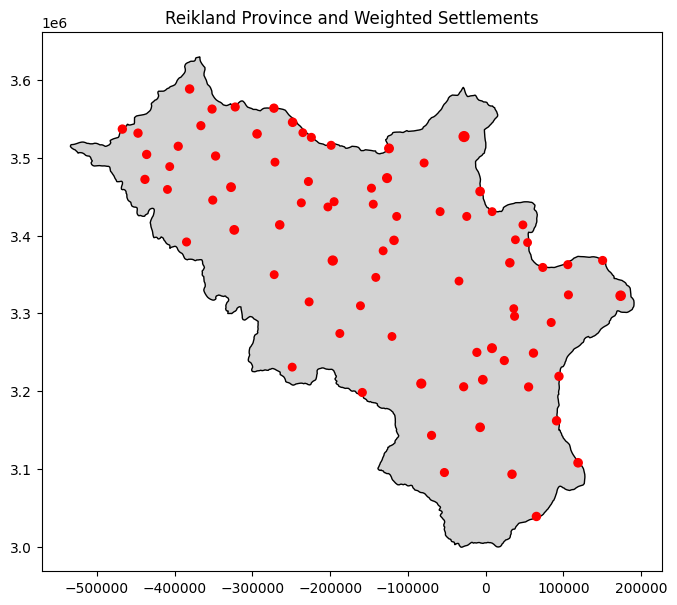

In [6]:
import rasterio.transform
import rasterio.features

# 1. Define pixel size (in the units of your CRS)
resolution = 100

# 2. Get the bounding box of the Reikland province
minx, miny, maxx, maxy = province.total_bounds

# 3. Create the 1D arrays for X and Y coordinates
x_coords = np.arange(minx, maxx, resolution)
y_coords = np.arange(maxy, miny, -resolution)

# Create the 2D meshgrid
xx, yy = np.meshgrid(x_coords, y_coords)

# 4. Create a mask to filter out pixels that fall outside the province boundaries
# We use rasterio's geometry_mask because it is highly optimized for this.
transform = rasterio.transform.from_origin(minx, maxy, resolution, resolution)

# rasterio returns True for pixels OUTSIDE the polygon, so we invert it with ~
province_mask = ~rasterio.features.geometry_mask(
    province.geometry,
    out_shape=(len(y_coords), len(x_coords)),
    transform=transform,
    invert=False
)

# Extract only the valid X and Y coordinates that lie inside the Reikland
valid_x = xx[province_mask]
valid_y = yy[province_mask]

print(f"Grid generated! Total pixels to calculate: {len(valid_x)}")

# Quick sanity check plot
fig, ax = plt.subplots(figsize=(8, 8))
province.plot(ax=ax, color='lightgrey', edgecolor='black')
settlements.plot(ax=ax, color='red', markersize=settlements['Weight']*10)
plt.title("Reikland Province and Weighted Settlements")
plt.show()

The plan now is to take each of the pixels, calculate euqlidian distance to each of the towns, divide it by the weight value. The lowest distance determines where we end up sticking a given pixel.

Calculating weighted distances for 20352694 pixels across 79 settlements...
Calculation complete!


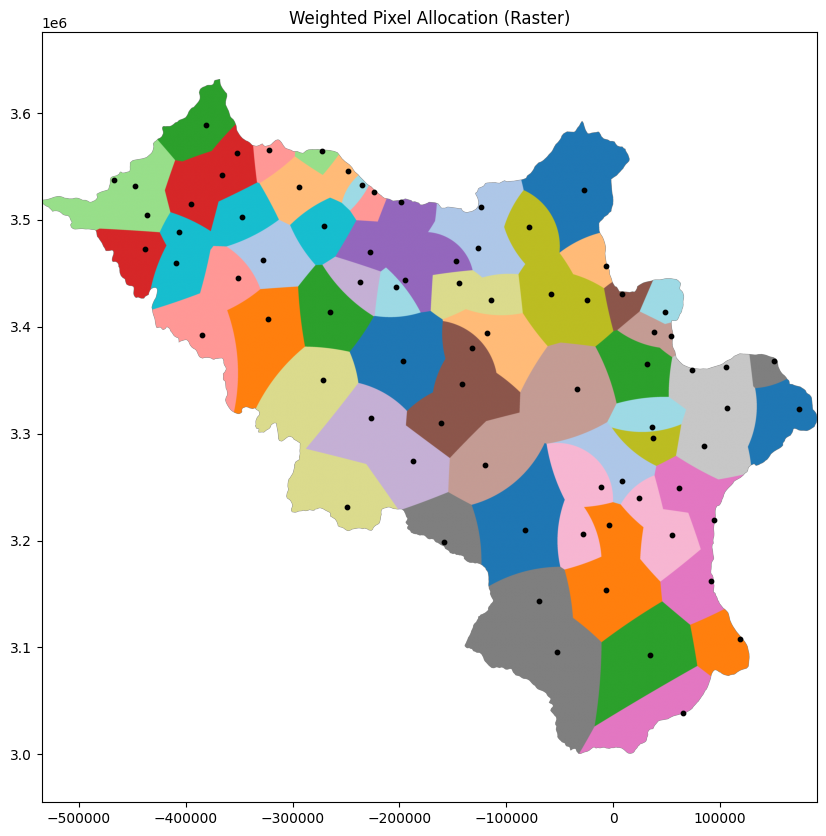

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numba import njit, prange

# 1. Prepare the coordinate arrays (Numba loves pure numpy arrays of the same type)
# We use the valid_x and valid_y from Cell 2
pixel_x = valid_x.astype(np.float64)
pixel_y = valid_y.astype(np.float64)

# Extract coordinates and weights from our settlements GeoDataFrame
settle_x = settlements.geometry.x.values.astype(np.float64)
settle_y = settlements.geometry.y.values.astype(np.float64)
weights = settlements['Weight'].values.astype(np.float64)

# 2. Define the Numba optimized function
# njit compiles this to machine code. parallel=True splits the 20M pixels across your CPU cores.
@njit(parallel=True)
def calculate_weighted_voronoi(px, py, sx, sy, w):
    num_pixels = len(px)
    num_settlements = len(sx)
    
    # Empty array to hold the winning settlement index for each pixel
    winners = np.empty(num_pixels, dtype=np.int32)
    
    # Loop over every pixel in parallel
    for i in prange(num_pixels):
        min_dist = np.inf
        best_settlement = -1
        
        # For this specific pixel, check the distance to every settlement
        for j in range(num_settlements):
            # Pythagorean theorem for straight-line distance
            dist = np.sqrt((px[i] - sx[j])**2 + (py[i] - sy[j])**2)
            
            # Apply the weight!
            weighted_dist = dist / w[j]
            
            # Check if this is the closest one so far
            if weighted_dist < min_dist:
                min_dist = weighted_dist
                best_settlement = j
                
        winners[i] = best_settlement
        
    return winners

# 3. Run the engine!
print(f"Calculating weighted distances for {len(pixel_x)} pixels across {len(settle_x)} settlements...")
winning_indices = calculate_weighted_voronoi(pixel_x, pixel_y, settle_x, settle_y, weights)
print("Calculation complete!")

# 4. Reassemble the 2D Grid
# Create an empty grid filled with a 'No Data' value (-1) to match our meshgrid shape from Cell 2
# province_mask.shape gives us the (rows, columns) of the bounding box
grid_shape = province_mask.shape
allocation_grid = np.full(grid_shape, fill_value=-1, dtype=np.int32)

# Pour the winning indices exactly back into the valid pixel slots we masked out
allocation_grid[province_mask] = winning_indices

# 5. Quick Visualization
plt.figure(figsize=(10, 10))
# Mask out the -1 (No Data) values so the outside of the province remains blank
masked_grid = np.ma.masked_where(allocation_grid == -1, allocation_grid)

# Plot the raster allocations
# extent ensures the image aligns with our geographic coordinates
plt.imshow(masked_grid, cmap='tab20', extent=[minx, maxx, miny, maxy], origin='upper')

# Plot the settlement points on top
plt.scatter(settle_x, settle_y, color='black', s=10, zorder=5)

plt.title("Weighted Pixel Allocation (Raster)")
plt.axis('equal')
plt.show()

Tracing polygons from the raster grid...
Clipping to the Reikland border...


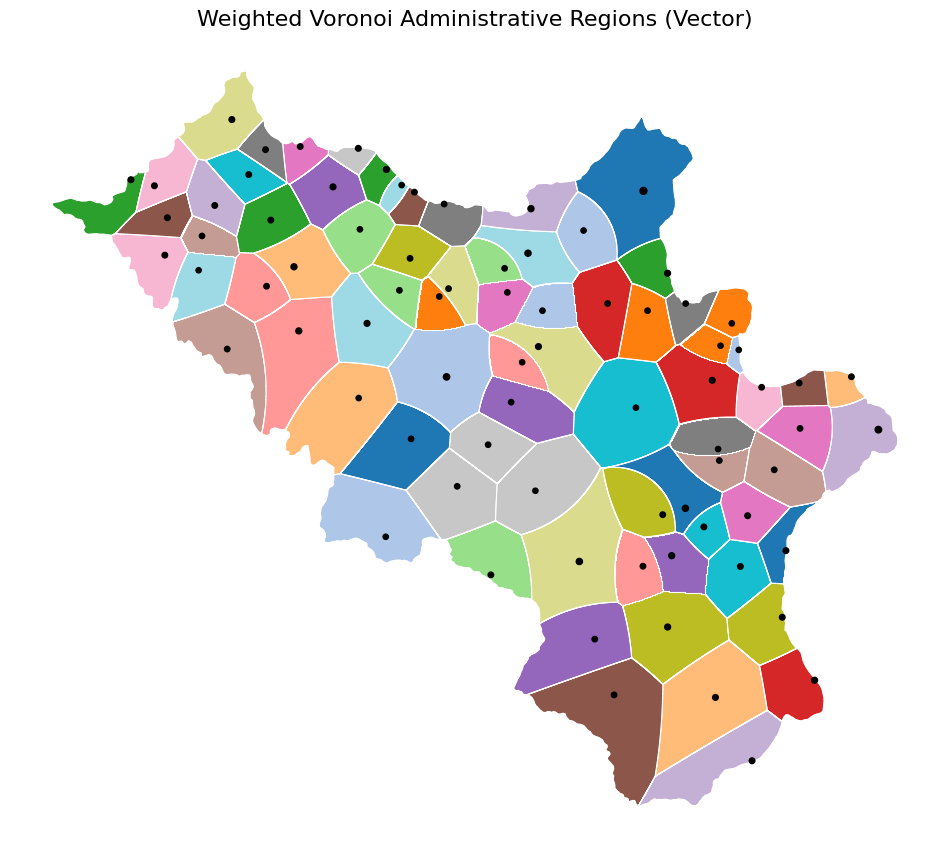

In [8]:
from shapely.geometry import shape

print("Tracing polygons from the raster grid...")

# 1. Extract vector shapes from the raster grid
# We use the transform from Cell 2 so the polygons inherit the exact geographic coordinates.
# We also mask out the -1 values so it ignores the space outside the province.
shapes_generator = rasterio.features.shapes(
    allocation_grid,
    mask=(allocation_grid != -1),
    transform=transform
)

# 2. Convert the raw GeoJSON-like outputs into Shapely geometries
polygons = []
settlement_indices = []

for geom, value in shapes_generator:
    polygons.append(shape(geom))
    settlement_indices.append(int(value)) # value is the ID of the winning settlement

# 3. Build the new GeoDataFrame
voronoi_gdf = gpd.GeoDataFrame(
    {'settlement_index': settlement_indices},
    geometry=polygons,
    crs=province.crs
)

# 4. Re-attach the settlement attributes (Name, Population, Weight)
# We temporarily add an index column to the settlements dataframe to match against
settlements['settlement_index'] = range(len(settlements))

# Merge the data. We drop the settlements geometry so we keep our new polygon boundaries.
voronoi_gdf = voronoi_gdf.merge(
    settlements.drop(columns='geometry'), 
    on='settlement_index', 
    how='left'
)

# 5. Smooth the outer edges
# The outer boundary currently looks like Minecraft blocks because of the grid. 
# We clip it against the original, smooth Reikland polygon to fix this.
print("Clipping to the Reikland border...")
final_voronoi = gpd.clip(voronoi_gdf, province)

# 6. Final Vector Plot!
fig, ax = plt.subplots(figsize=(12, 12))
final_voronoi.plot(ax=ax, column='Name', cmap='tab20', edgecolor='white', linewidth=0.8)
# Plot the towns on top
settlements.plot(ax=ax, color='black', markersize=settlements['Weight']*5, zorder=5)

plt.title("Weighted Voronoi Administrative Regions (Vector)", fontsize=16)
plt.axis('off')
plt.show()

In [9]:
# Define the name for your new layer
new_layer_name = "reikland_admin_regions"

print(f"Saving weighted Voronoi polygons to layer '{new_layer_name}'...")

# Export to the existing GeoPackage
# By specifying the layer name and the GPKG driver, GeoPandas will add this as a new table.
final_voronoi.to_file(gpkg_path, layer=new_layer_name, driver="GPKG")

print("Export complete! Your map is ready for QGIS.")

Saving weighted Voronoi polygons to layer 'reikland_admin_regions'...
Export complete! Your map is ready for QGIS.
